# **Prediksi Status Berlangganan Deposito | Support Vector Machine (SVM)**

Model prediksi apakah nasabah berlangganan deposito? menggunakan algoritma Support Vector Machine (SVM).

## 1. Data Understanding & Exploratory Data Analysis

### 1.1 Import Library

In [109]:
# Impor pustaka yang diperlukan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import ttk, messagebox

### 1.2 Import & Data Understanding 

In [110]:
# Import 'Assignment-2_Data.csv' dataset
bank_before = pd.read_csv('Assignment-2_Data.csv')

In [111]:
# Tampilkan 5 baris terats
print('\n5 baris teratas:')
bank_before.head()


5 baris teratas:


,Id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1001,999.0,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,1002,44.0,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,1003,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,1004,47.0,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,1005,33.0,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [112]:
# Tamplikan informasi dataset 
print('\nRingkasan informasi:')
bank_before.info()


Ringkasan informasi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         45211 non-null  int64  
 1   age        45202 non-null  float64
 2   job        45211 non-null  object 
 3   marital    45211 non-null  object 
 4   education  45211 non-null  object 
 5   default    45211 non-null  object 
 6   balance    45208 non-null  float64
 7   housing    45211 non-null  object 
 8   loan       45211 non-null  object 
 9   contact    45211 non-null  object 
 10  day        45211 non-null  int64  
 11  month      45211 non-null  object 
 12  duration   45211 non-null  int64  
 13  campaign   45211 non-null  int64  
 14  pdays      45211 non-null  int64  
 15  previous   45211 non-null  int64  
 16  poutcome   45211 non-null  object 
 17  y          45211 non-null  object 
dtypes: float64(2), int64(6), object(10)
memory usage: 6.2+ MB


In [113]:
# Tamplikan dimensi dataset 
print('\nDimensi dataset:')
print('Jumlah baris:', bank_before.shape[0])
print('Jumlah kolom:', bank_before.shape[1])


Dimensi dataset:
Jumlah baris: 45211
Jumlah kolom: 18


In [114]:
# TFungsi menampilkan nilai unik
def unique_values(features_name):
    print(f'== Nilai unik fitur {features_name} ==')
    print(f'Total nilai unik :', bank_before[features_name].nunique())
    print('\nNilai unik', bank_before[features_name].unique())
    print('\n')

In [115]:
# Tamilkan kolom dataset
print('\nFitur dalam dataset:')
bank_before.columns


Fitur dalam dataset:


Index(['Id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [116]:
# Panggil fungsi nilai 
unique_values('y')

== Nilai unik fitur y ==
Total nilai unik : 2

Nilai unik ['no' 'yes']




In [117]:
# Hapus fitur 'Id'
bank_before = bank_before.drop('Id', axis=1)

In [118]:
# Simpan kolom numerik dan objek pada variabel
num_cols = bank_before.select_dtypes(include=['int64', 'float64']).columns
cat_cols = bank_before.select_dtypes(include=['category', 'object']).columns

### Sampling Data

Untuk dataset dengan 45211 baris dengan jumlah 18 kolom ini, kami memutuskan untuk mengambil sample data sebanyak 10% dari dataset.

In [119]:
bank = bank_before.groupby('y', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))
bank.shape

/tmp/ipykernel_3658/2819078787.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bank = bank_before.groupby('y', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))


(4521, 17)

### 1.3 Missing Value & Data Duplikat 

#### 1.3.1 Missing Value

In [120]:
# Tampilkan total missing value
print('\nTotal missing value:', bank.isnull().sum().sum())


Total missing value: 0


In [121]:
# # Tampilkan missing value per fitur 
# print('\nMissing value per fitur:')
# bank.isnull().sum()

Nilai kosong: 
- Fitur 'age' -> 9
- Fitur 'balance' -> 3
 

#### 1.3.2 Data Duplikat 

In [122]:
# Tamplikan total data duplikat 
print('\nTotal data duplikat:', bank_before.duplicated().sum())


Total data duplikat: 0


### Encoding

In [123]:
bank['y'] = bank['y'].map({   
    'no': -1,
    'yes': 1
})

In [124]:
# Encoding fitur kategori
for col in bank.select_dtypes(include=['category', 'object']).columns:
    bank[col], uniques = pd.factorize(bank[col])

    print(f'\nFitur {col}')
    for i, val in enumerate(uniques):
        print(f'{i} -> {val}')


Fitur job
0 -> unemployed
1 -> blue-collar
2 -> technician
3 -> services
4 -> housemaid
5 -> admin.
6 -> management
7 -> entrepreneur
8 -> retired
9 -> self-employed
10 -> unknown
11 -> student

Fitur marital
0 -> single
1 -> married
2 -> divorced

Fitur education
0 -> secondary
1 -> tertiary
2 -> primary
3 -> unknown

Fitur default
0 -> no
1 -> yes

Fitur housing
0 -> no
1 -> yes

Fitur loan
0 -> no
1 -> yes

Fitur contact
0 -> cellular
1 -> unknown
2 -> telephone

Fitur month
0 -> jan
1 -> may
2 -> jul
3 -> feb
4 -> aug
5 -> nov
6 -> apr
7 -> jun
8 -> oct
9 -> sep
10 -> dec
11 -> mar

Fitur poutcome
0 -> unknown
1 -> failure
2 -> other
3 -> success


### 1.4 Exploratory Data Analysis

In [125]:
# Tampilkan list fitur 
print('\nFitur numerik:', num_cols)
print('\nFitur kategorikal:', cat_cols)


Fitur numerik: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

Fitur kategorikal: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


#### 1.4.1 Multivariate Analysis

In [126]:
# Tampilkan statistik dataset
print('\nStatistik dataset:')
bank_before.describe()


Statistik dataset:


,age,balance,day,duration,campaign,pdays,previous
count,45202.000000,45208.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.954714,1362.346620,15.806419,258.163080,2.763841,40.197828,0.580323
std,11.539144,3044.852387,8.322476,257.527812,3.098021,100.128746,2.303441
min,-1.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,999.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [127]:
# # Tamplikan grafik pairplot 
# sns.pairplot(bank_before)
# plt.show()

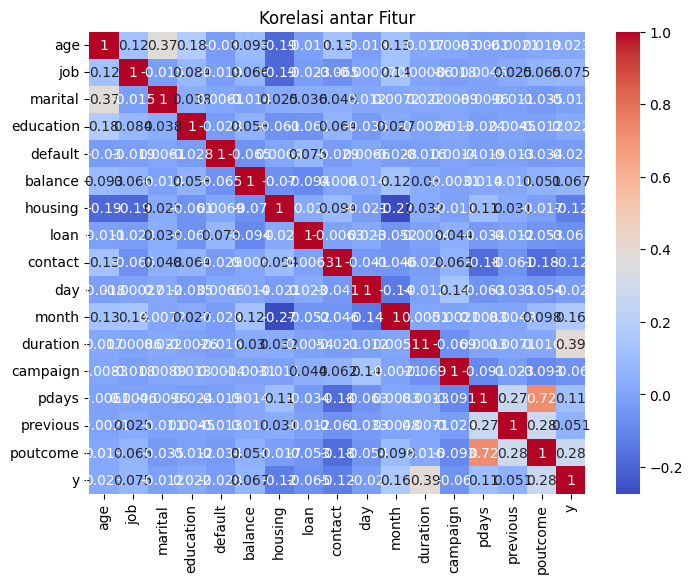

In [128]:
# Korelasi antar fitur
correlation = bank.corr()


# Visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi antar Fitur')
plt.show()

#### 1.4.2 Univariate Analysis

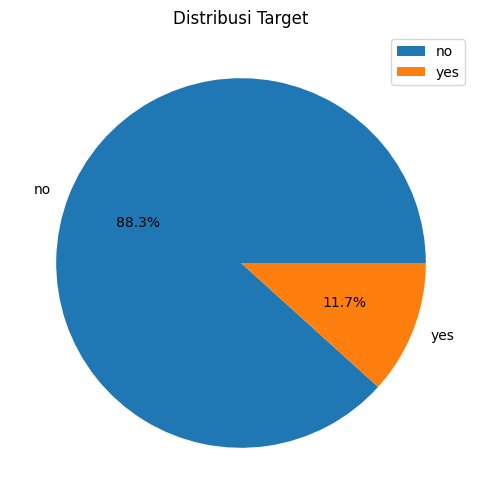

In [129]:
# Distribusi fitur target
counts = bank_before['y'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Distribusi Target')
plt.legend(['no', 'yes'])
plt.show()


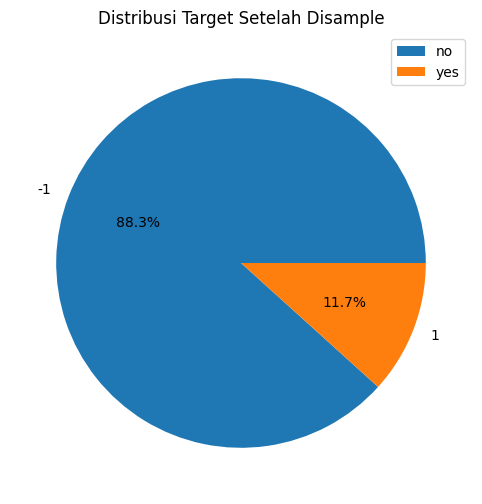

In [130]:
# Distribusi fitur target
counts = bank['y'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Distribusi Target Setelah Disample')
plt.legend(['no', 'yes'])
plt.show()


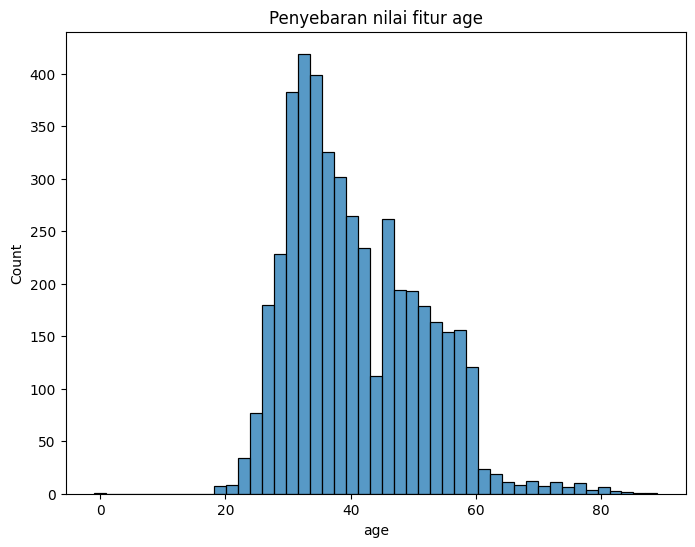

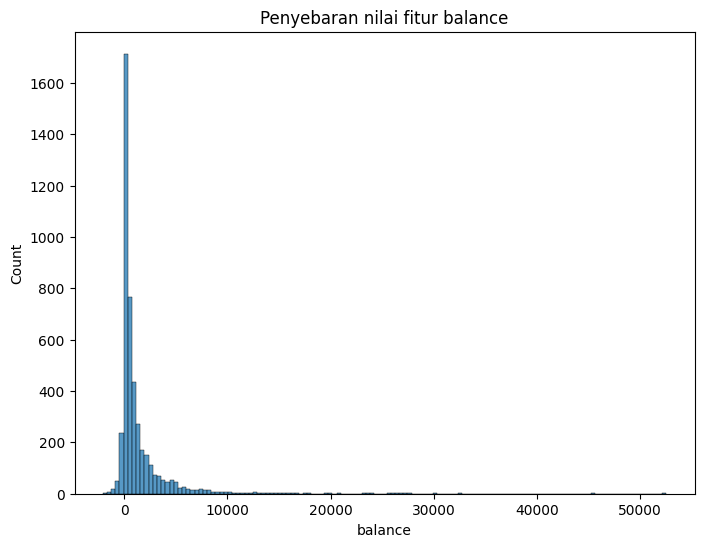

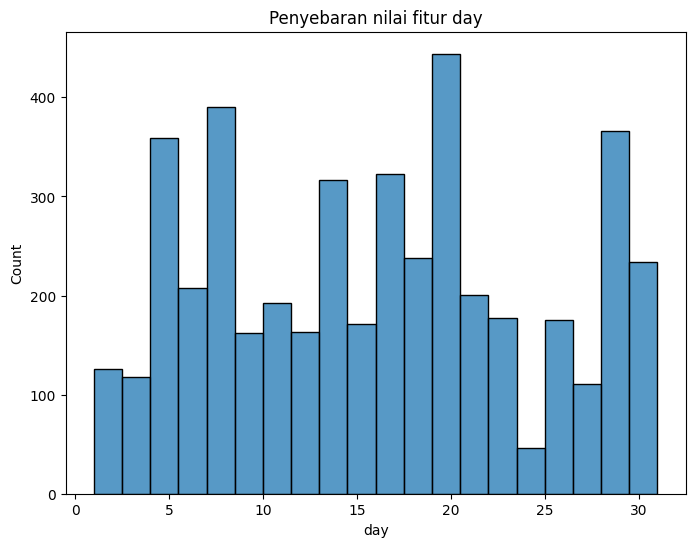

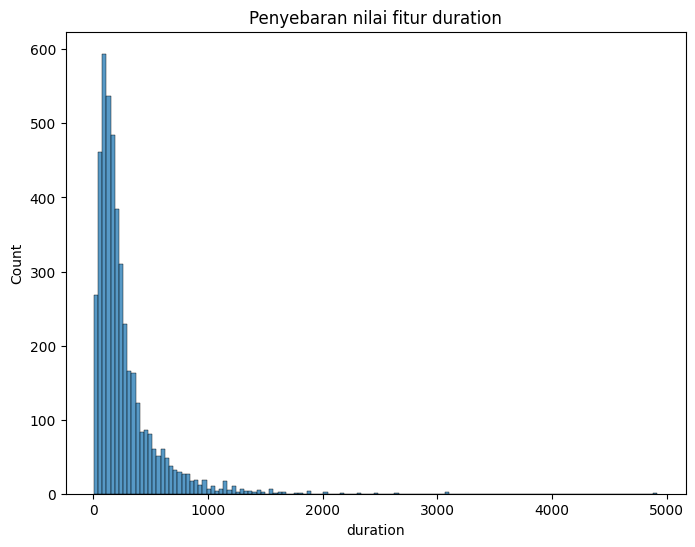

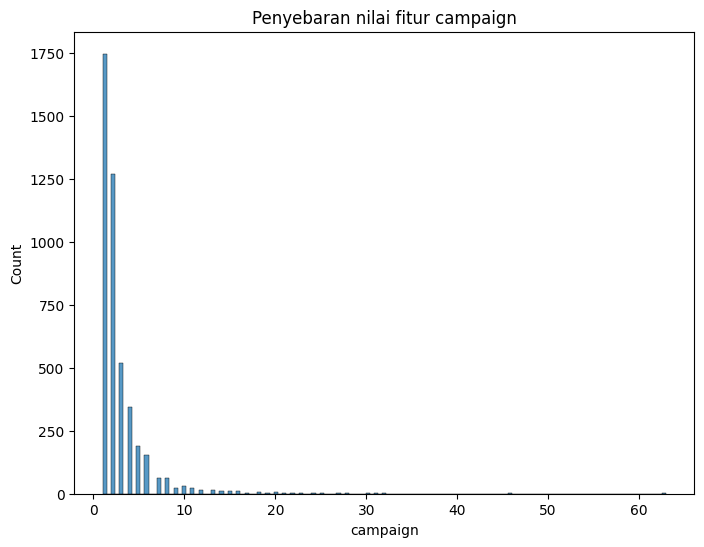

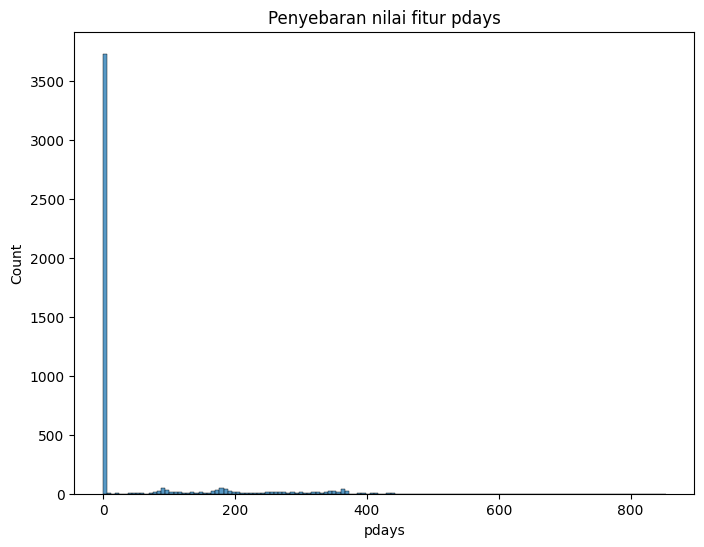

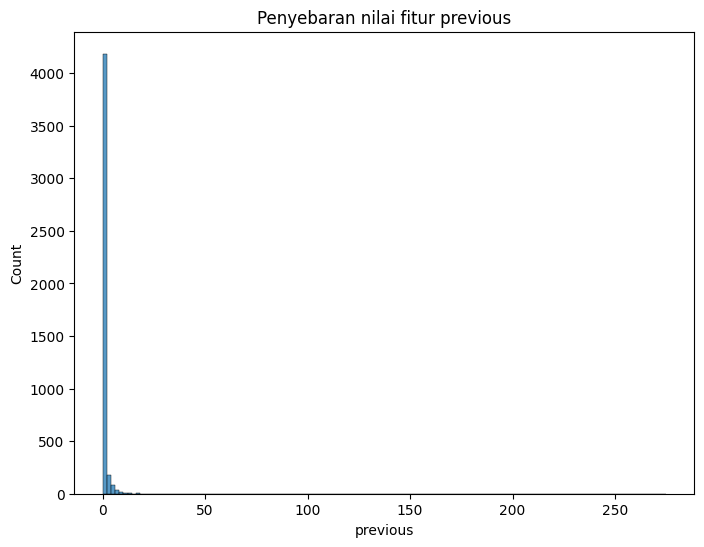

In [131]:
# Distribusi fitur numerik 
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=bank[col])
    plt.title(f'Penyebaran nilai fitur {col}')
    plt.show()

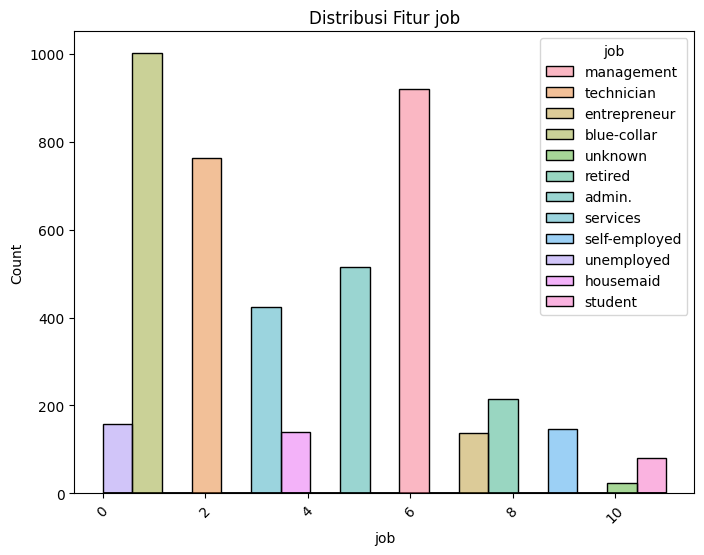

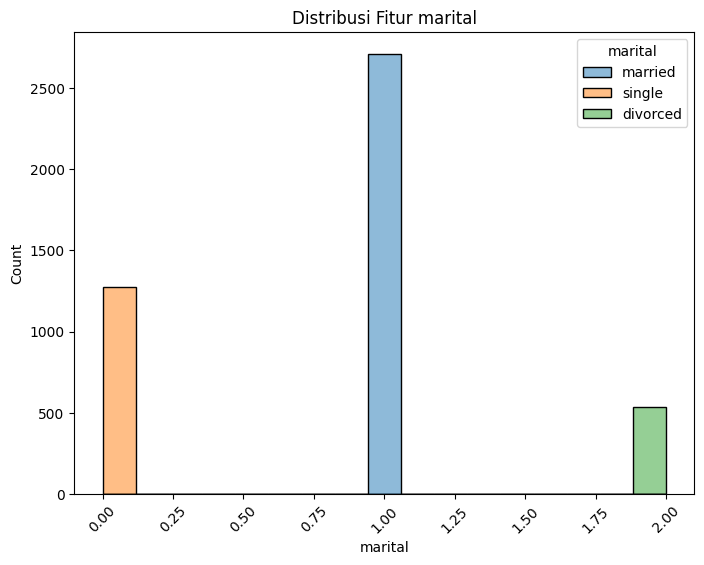

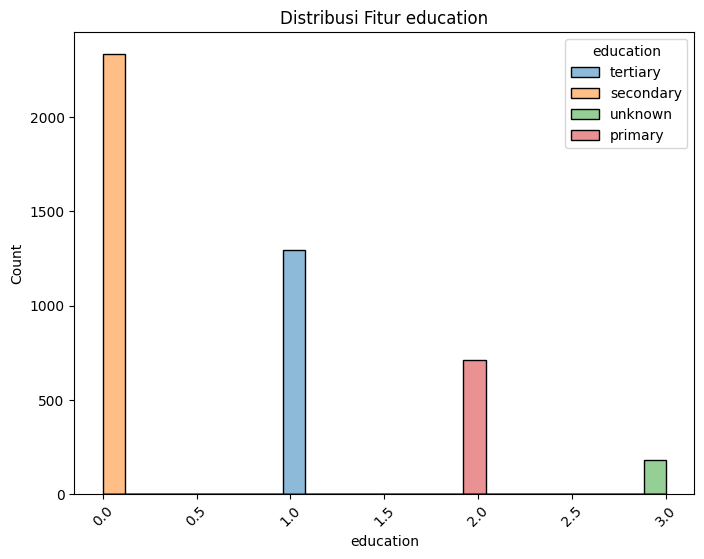

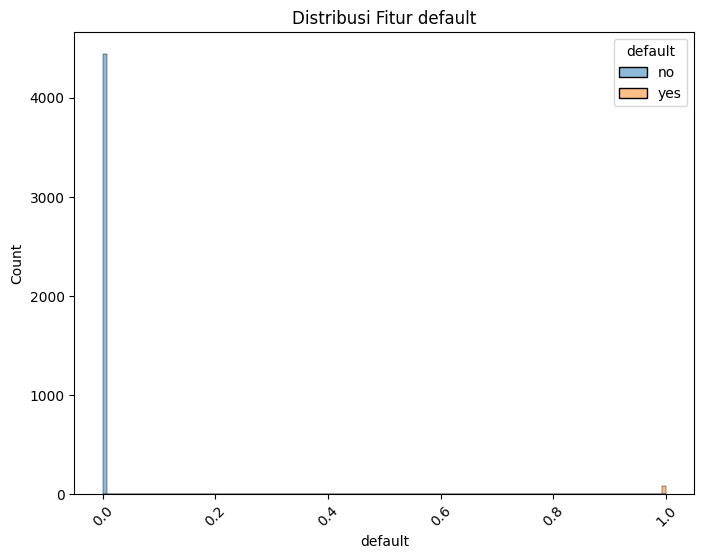

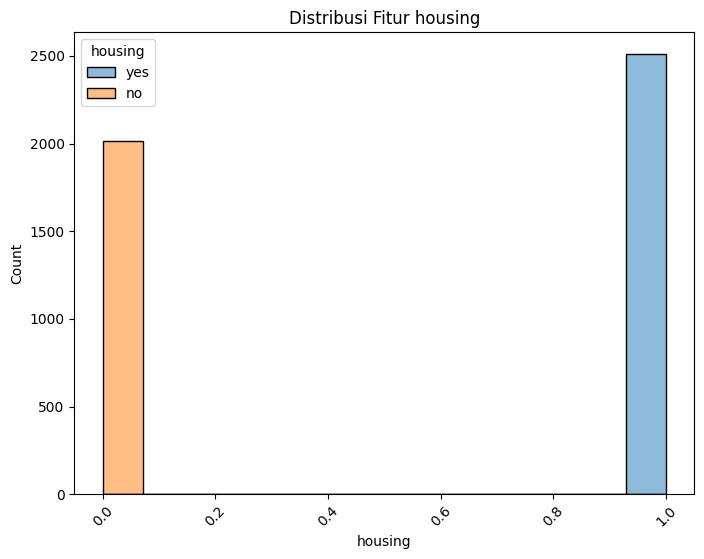

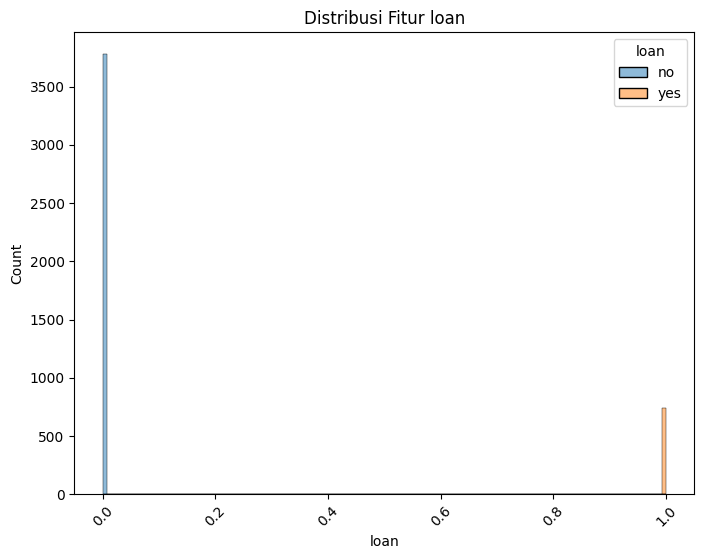

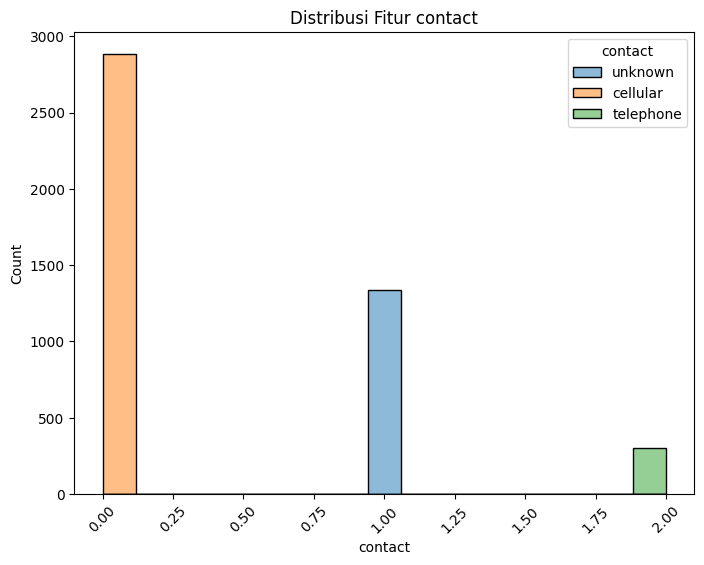

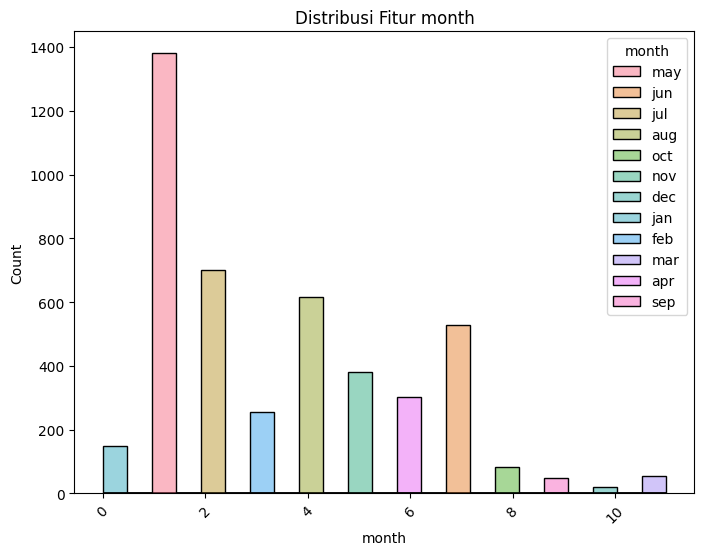

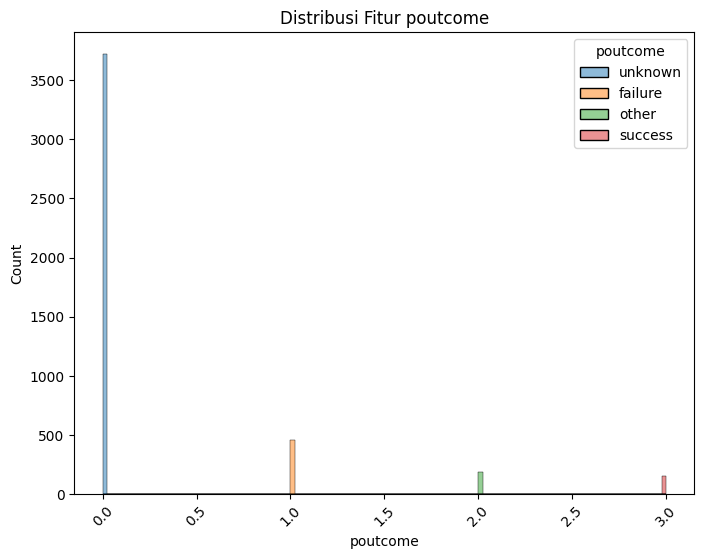

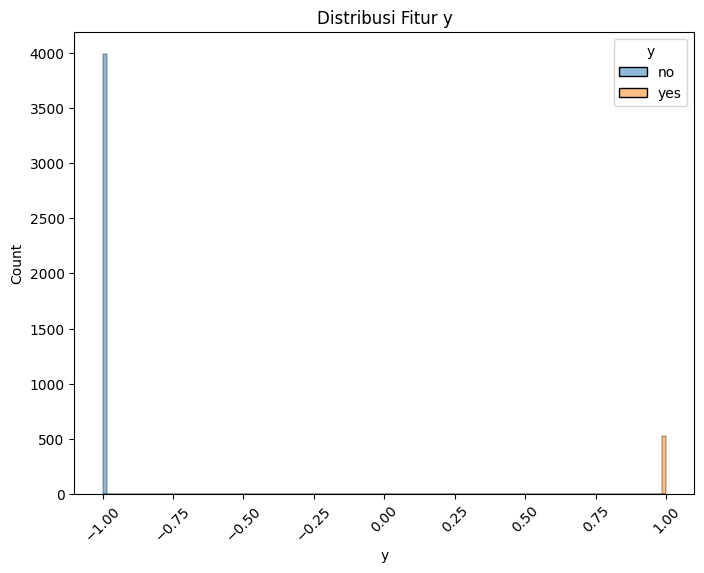

In [132]:
# Tampilkan ditribusi fitur kategorikal
for col in cat_cols:
    plt.figure(figsize=(8, 6))
    plt.xticks(rotation=45)
    sns.histplot(x=bank[col], hue=bank_before[col])
    plt.title(f'Distribusi Fitur {col}')
    plt.show()

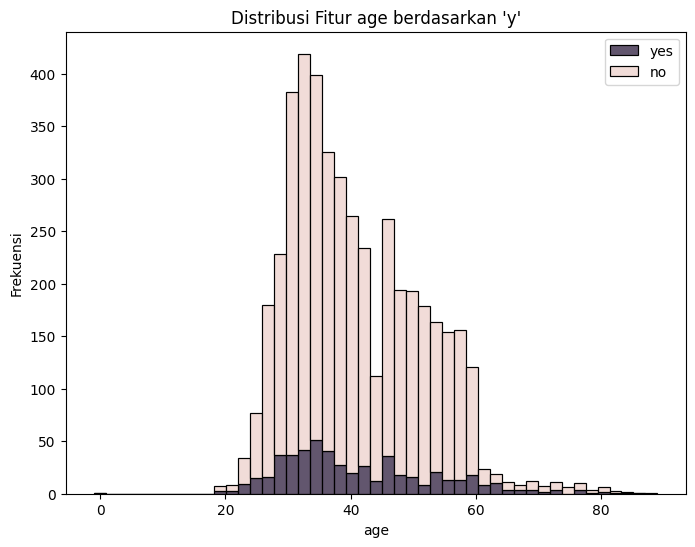

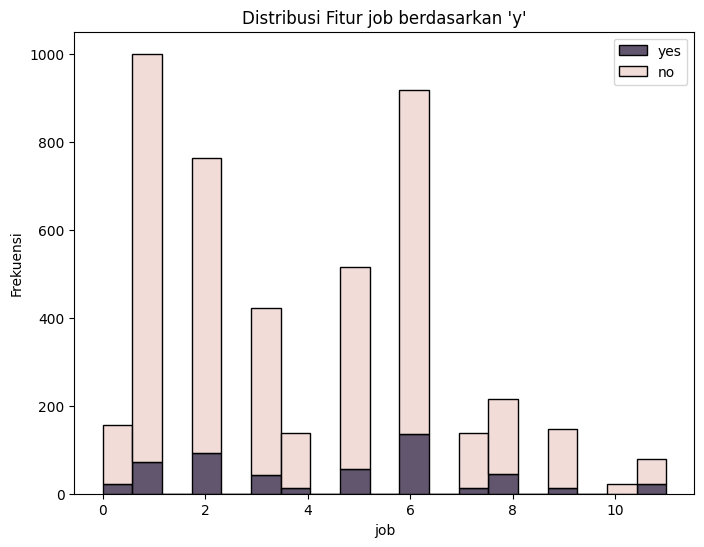

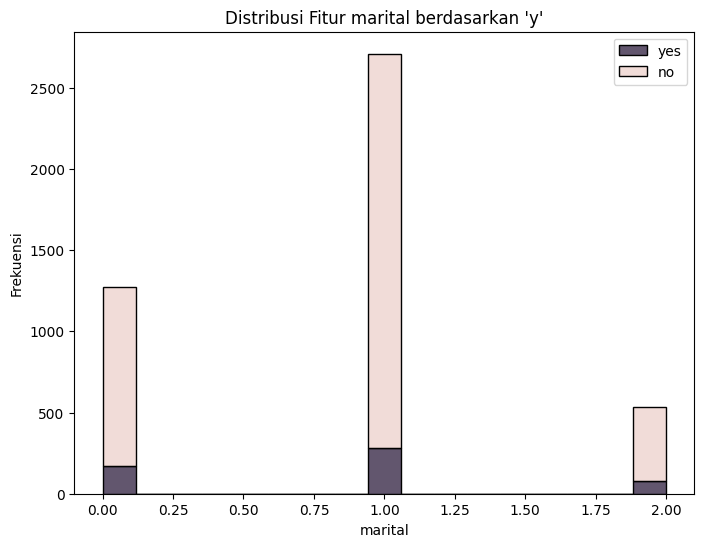

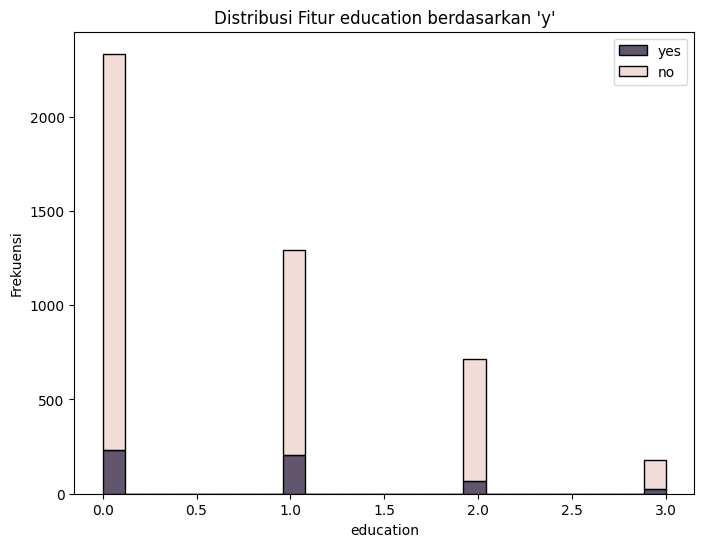

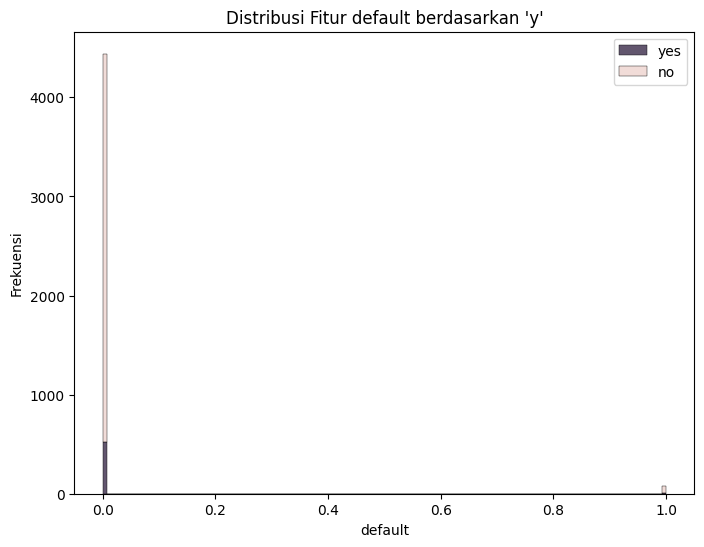

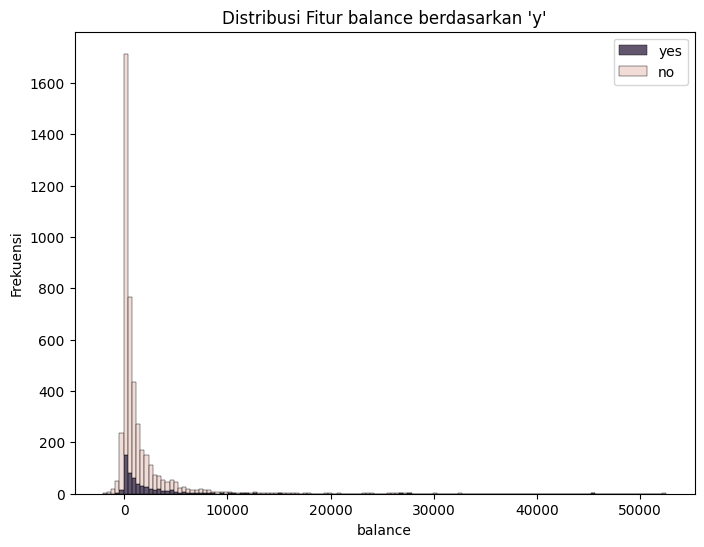

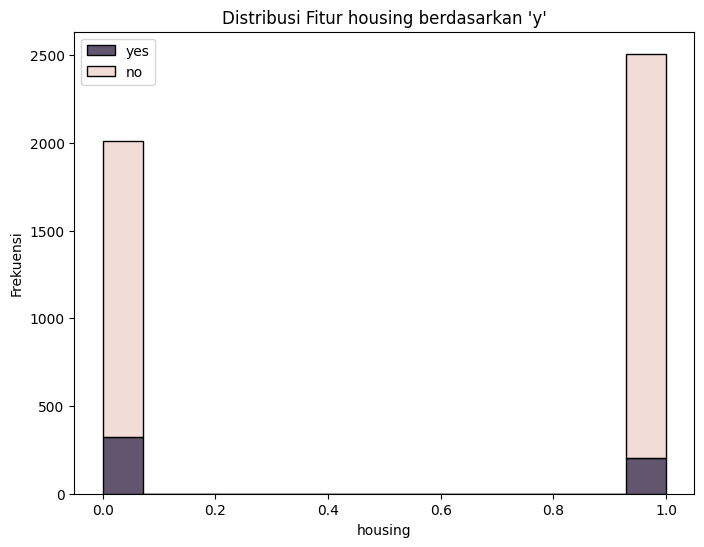

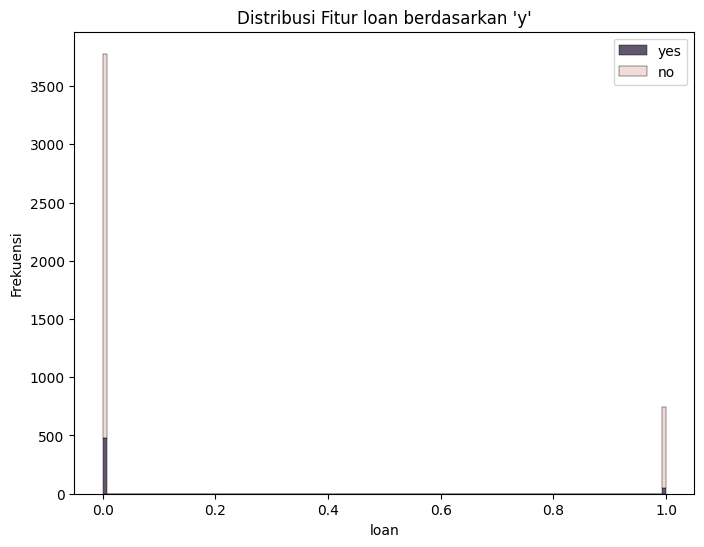

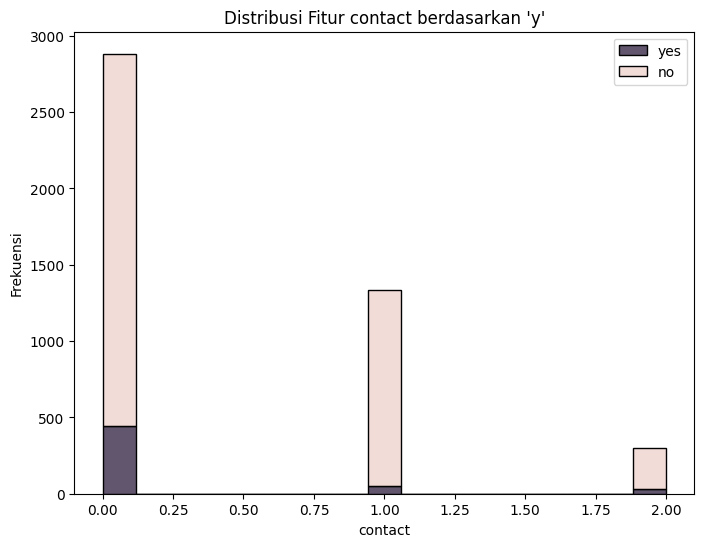

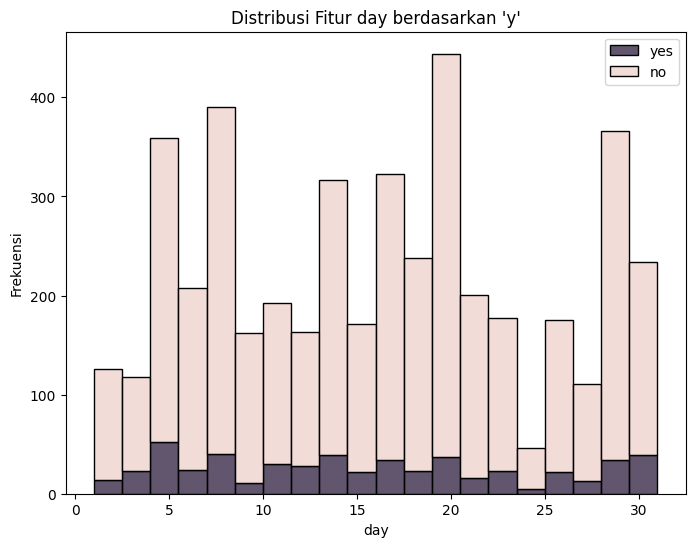

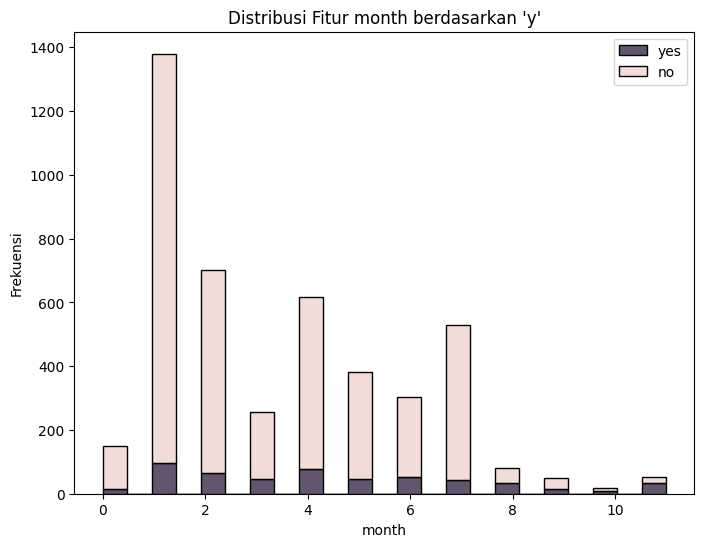

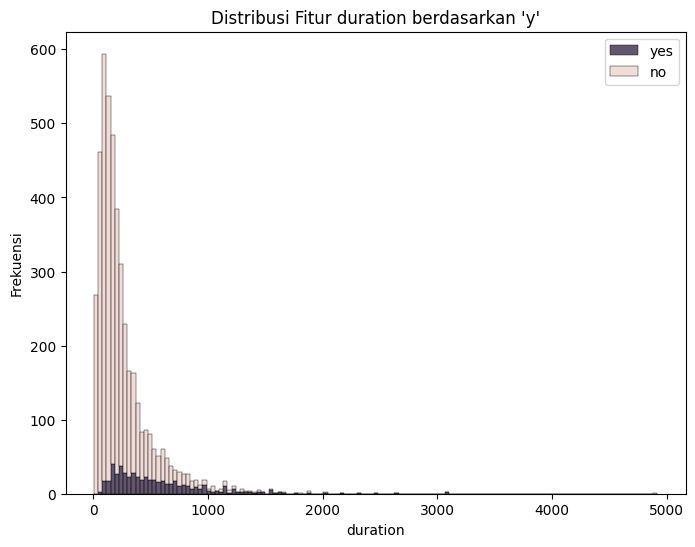

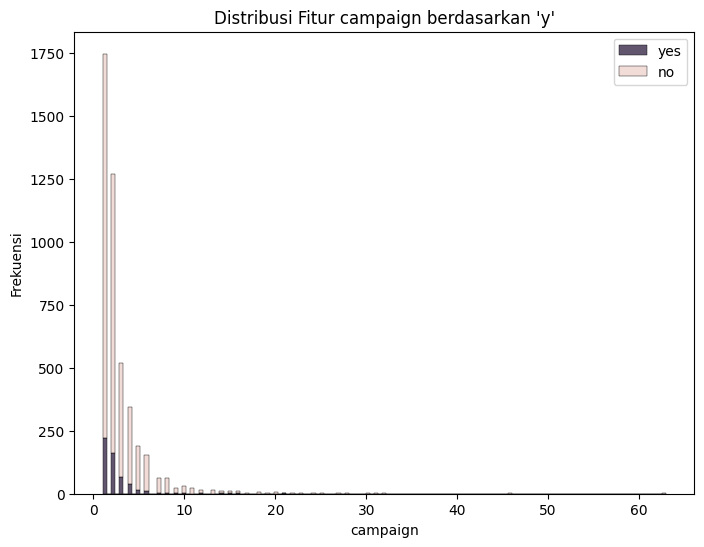

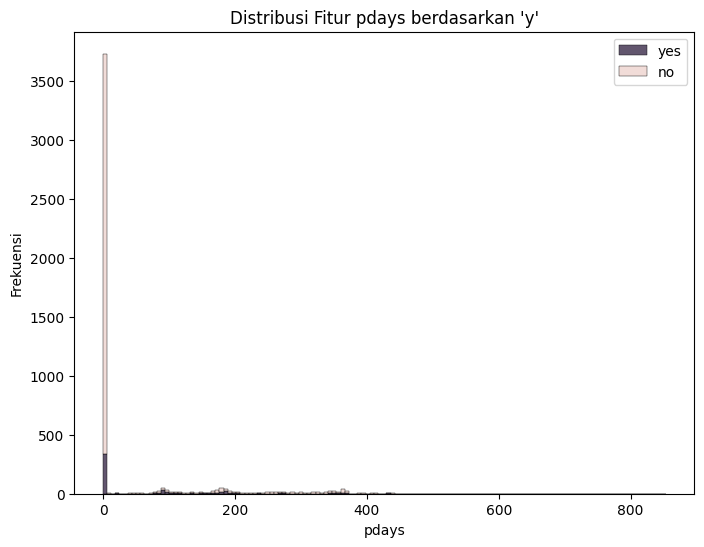

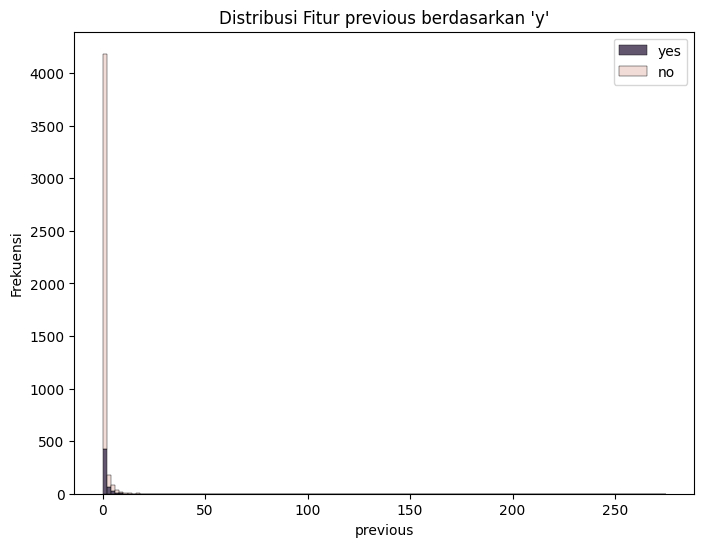

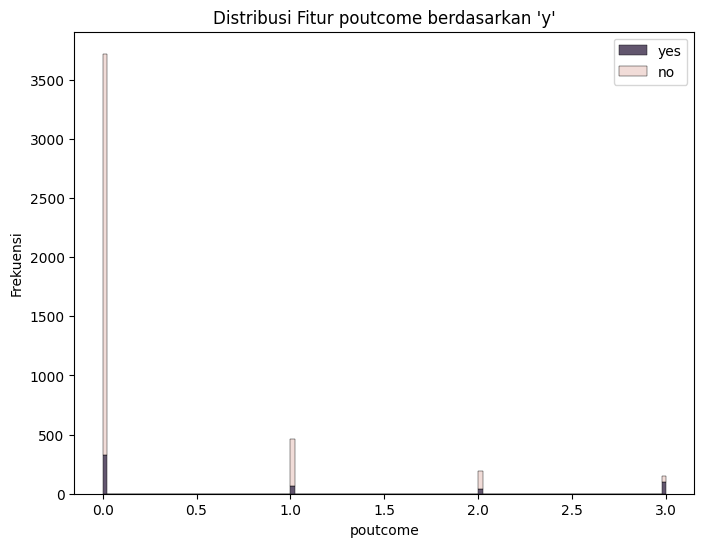

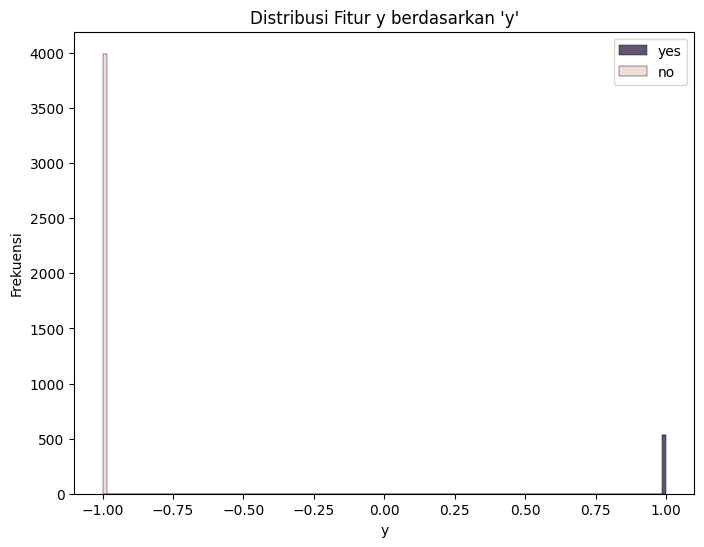

In [133]:
# Penyebaran fitur independent terhadap target 
for col in bank.columns:
    plt.figure(figsize=(8, 6))
    # plt.xticks(rotation=45)
    sns.histplot(data=bank, x=bank[col], hue='y', multiple='stack')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.title(f"Distribusi Fitur {col} berdasarkan 'y'")
    plt.legend(['yes', 'no'])
    plt.show()

In [134]:
# sns.pairplot(bank)
# plt.show()

In [135]:
import numpy as np
import pandas as pd
import random

# --- 1. Class Scaler Manual (Pengganti StandardScaler Sklearn) ---
class ManualScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        # Hindari pembagian nol
        self.std[self.std == 0] = 1.0

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# --- 2. Class SVM RBF (Algorithm: Simplified SMO) ---
class SVM_RBF:
    def __init__(self, C=1.0, gamma=0.5, tol=0.01, max_passes=5):
        self.C = C
        self.gamma = gamma
        self.tol = tol
        self.max_passes = max_passes
        self.alphas = None
        self.b = 0
        self.X_train = None
        self.y_train = None

    # Fungsi Kernel RBF (Gaussian)
    def kernel_rbf(self, x1, x2):
        # Menggunakan norma L2 kuadrat: ||x1 - x2||^2
        dist = np.linalg.norm(x1 - x2) ** 2
        return np.exp(-self.gamma * dist)

    def fit(self, X, y):
        # Pastikan input numpy array
        X = np.array(X)
        y = np.array(y)
        
        m, n = X.shape
        self.alphas = np.zeros(m)
        self.b = 0
        self.X_train = X
        self.y_train = y
        
        passes = 0
        print(f"Training SVM RBF (Data size: {m})... Sabar ya bang!")
        
        # Simplified SMO Algorithm
        while passes < self.max_passes:
            num_changed_alphas = 0
            for i in range(m):
                # Hitung error Ei
                # Prediksi f(x_i) = sum(alpha_j * y_j * K(x_j, x_i)) + b
                Ei = self.predict_single(X[i]) - y[i]
                
                # Cek kondisi KKT
                if (y[i] * Ei < -self.tol and self.alphas[i] < self.C) or \
                   (y[i] * Ei > self.tol and self.alphas[i] > 0):
                    
                    # Pilih j secara random (selain i)
                    j = i
                    while j == i:
                        j = int(random.uniform(0, m))
                    
                    Ej = self.predict_single(X[j]) - y[j]
                    
                    # Simpan alpha lama
                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]
                    
                    # Hitung batas L dan H
                    if y[i] != y[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])
                    
                    if L == H:
                        continue
                    
                    # Hitung eta (2*Kij - Kii - Kjj)
                    kij = self.kernel_rbf(X[i], X[j])
                    kii = self.kernel_rbf(X[i], X[i])
                    kjj = self.kernel_rbf(X[j], X[j])
                    eta = 2 * kij - kii - kjj
                    
                    if eta >= 0:
                        continue
                    
                    # Update alpha j
                    self.alphas[j] -= y[j] * (Ei - Ej) / eta
                    self.alphas[j] = max(L, min(H, self.alphas[j]))
                    
                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue
                    
                    # Update alpha i
                    self.alphas[i] += y[i] * y[j] * (alpha_j_old - self.alphas[j])
                    
                    # Hitung b (bias)
                    b1 = self.b - Ei - y[i] * (self.alphas[i] - alpha_i_old) * kii - \
                         y[j] * (self.alphas[j] - alpha_j_old) * kij
                    b2 = self.b - Ej - y[i] * (self.alphas[i] - alpha_i_old) * kij - \
                         y[j] * (self.alphas[j] - alpha_j_old) * kjj
                    
                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2
                    
                    num_changed_alphas += 1
            
            if num_changed_alphas == 0:
                passes += 1
            else:
                passes = 0
                
        print("Training Selesai!")

    # Prediksi untuk satu data point (Internal)
    def predict_single(self, x):
        # f(x) = sum(alpha_j * y_j * K(x_j, x)) + b
        # Kita hanya perlu hitung yang alpha > 0 (Support Vectors) untuk performa
        support_indices = np.where(self.alphas > 0)[0]
        prediction = 0
        for idx in support_indices:
            prediction += self.alphas[idx] * self.y_train[idx] * self.kernel_rbf(self.X_train[idx], x)
        return prediction + self.b

    # Prediksi batch (Untuk user)
    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = []
        for x in X_test:
            res = self.predict_single(x)
            predictions.append(1 if res >= 0 else -1)
        return np.array(predictions)

# --- 3. Eksekusi Training (Integrasi dengan datamu) ---

# A. Split Data (Manual karena no sklearn)
# Menggunakan 'bank' dataframe yang sudah kamu encode sebelumnya
data_np = bank.values
np.random.shuffle(data_np)

split_ratio = 0.8
split_idx = int(len(data_np) * split_ratio)

X_all = data_np[:, :-1] # Semua kolom kecuali terakhir
y_all = data_np[:, -1]  # Kolom terakhir (y)

# Pastikan y bernilai -1 dan 1 (sudah kamu lakukan di cell 66)
X_train_raw = X_all[:split_idx]
y_train = y_all[:split_idx]
X_test_raw = X_all[split_idx:]
y_test = y_all[split_idx:]

# B. Scaling Data (SANGAT PENTING BUAT RBF)
scaler = ManualScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# C. Train Model
# Gamma kecil = boundary lebih halus, Gamma besar = boundary detail (awas overfitting)
model_rbf = SVM_RBF(C=1.0, gamma=0.1, max_passes=3) 
model_rbf.fit(X_train, y_train)

# D. Evaluasi
y_pred = model_rbf.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Akurasi Model RBF: {accuracy * 100:.2f}%")

Train size: (3616, 16), Test size: (905, 16)
Training SVM RBF (Data size: 3616)... Sabar ya bang!


KeyboardInterrupt: 

Sedang menyiapkan visualisasi... (Mungkin agak berat karena pure numpy)
Training SVM RBF (Data size: 200)... Sabar ya bang!
Training Selesai!


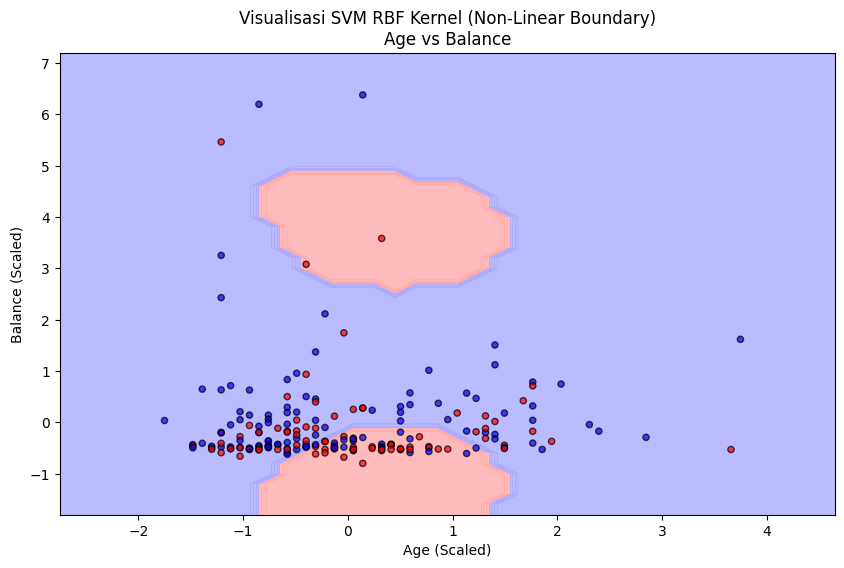

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def visualize_svm_boundary(X_full, y_full, feature_indices=(0, 1), feature_names=None):
    """
    X_full: Data mentah (belum discaled)
    y_full: Label target
    feature_indices: Tuple index kolom yang mau divisualisasi (contoh: (0, 5) untuk Age vs Balance)
    """
    
    print("Sedang menyiapkan visualisasi... (Mungkin agak berat karena pure numpy)")
    
    # 1. Ambil 2 fitur saja
    f1, f2 = feature_indices
    X_2d = X_full[:, [f1, f2]]
    y_2d = y_full
    
    # 2. Scaling data 2D ini (Wajib buat SVM)
    scaler_viz = ManualScaler()
    X_2d_scaled = scaler_viz.fit_transform(X_2d)
    
    # 3. Train Model RBF khusus untuk 2D ini
    # Kita pakai C agak besar biar boundary-nya kelihatan tegas
    # Gamma 'auto' (atau diset manual misal 0.5)
    model_viz = SVM_RBF(C=1.0, gamma=0.5, max_passes=3)
    model_viz.fit(X_2d_scaled, y_2d)
    
    # 4. Buat Meshgrid (Jaring-jaring titik buat background warna)
    h = 0.2  # Step size (makin kecil makin halus tapi lama)
    x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
    y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # 5. Prediksi semua titik di background
    # (Kita flatten dulu biar jadi list panjang)
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Prediksi manual loop (karena class kita pure python)
    Z = model_viz.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    # 6. Plotting
    plt.figure(figsize=(10, 6))
    
    # Warna background (Decision Boundary)
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF']) # Merah muda (No), Biru muda (Yes)
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])  # Merah tua, Biru tua
    
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    
    # Plot titik data asli
    plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, 
                cmap=cmap_bold, edgecolor='k', s=20, alpha=0.7)

    # Labeling
    name1 = feature_names[f1] if feature_names else f"Feature {f1}"
    name2 = feature_names[f2] if feature_names else f"Feature {f2}"
    
    plt.title(f"Visualisasi SVM RBF Kernel (Non-Linear Boundary)\n{name1} vs {name2}")
    plt.xlabel(f"{name1} (Scaled)")
    plt.ylabel(f"{name2} (Scaled)")
    plt.show()

# --- EKSEKUSI VISUALISASI ---

# Definisikan nama kolom biar jelas (sesuaikan dengan urutan datamu)
# Misal kolom ke-0 itu Age, kolom ke-5 itu Balance (cek dataframe-mu)
col_names = ["Age", "Job", "Marital", "Education", "Default", "Balance", "Housing", "Loan"] 
# (List di atas cuma contoh, sesuaikan urutan aslimu!)

# Pilih 2 fitur yang mau dilihat. 
# Coba (0, 5) kalau mau lihat Age vs Balance
# Karena prosesnya berat, kita ambil sampel 200 data saja buat visualisasi
subset_idx = np.random.choice(len(X_all), 200, replace=False)
X_subset = X_all[subset_idx]
y_subset = y_all[subset_idx]

# Jalankan fungsi
visualize_svm_boundary(X_subset, y_subset, feature_indices=(0, 5), feature_names=col_names)

In [ ]:
bank['y'].value_counts()

y
-1    529
 1    529
Name: count, dtype: int64

In [ ]:
np.random.seed(42)

data_major = bank[bank['y'] == -1]
data_minor = bank[bank['y'] == 1]

n_major = len(data_major)
n_minor = len(data_minor)

idx_major = data_major.index

idx_random = np.random.choice(idx_major, size=n_minor, replace=True)
data_major_over = bank.loc[idx_random]
bank = pd.concat([data_major_over, data_minor])

In [ ]:
X = bank.drop('y', axis=1)
y = bank['y']

In [ ]:
X = (X - X.mean()) / (X.std() - 1e-9)

In [ ]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    idx_0 = np.where(y == -1)[0]
    idx_1 = np.where(y == 1)[0]

    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)

    train_0 = int(len(idx_0) * size)
    train_1 = int(len(idx_1) * size)

    train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
    test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    return X_train, y_train, X_test, y_test

In [ ]:
X_train, y_train, X_test, y_test = split_data(X, y, size=0.8)

In [ ]:
print(f"X_train {X_train.shape}")
print(f"y_train {y_train.shape}")
print(f"X_test {X_test.shape}")
print(f"y_test {y_test.shape}")

X_train (846, 16)
y_train (846,)
X_test (212, 16)
y_test (212,)


In [ ]:
def train_svm(X, y, learning_rate=0.0001, lambda_param=0.01, iteration=2000):
    n_sampled, n_features = X.shape[0], X.shape[1]
    w = [0.0] * n_features
    b = 0.0

    # Convert X to numpy array for easier indexing
    X_np = X.values if hasattr(X, 'values') else X

    for _ in range(iteration):
        for idx, x_i in enumerate(X_np):
            y_i = y.iloc[idx]
            approx = sum(x_i[j] * w[j] for j in range(n_features)) + b
            condition = y_i * approx >= 1

            if condition:
                for j in range(n_features):
                    w[j] -= learning_rate * (2 * lambda_param * w[j])
            else:
                for j in range(n_features):
                    w[j] -= learning_rate * (2 * lambda_param * w[j] - x_i[j] * y_i)
                b -= learning_rate * y_i
    return w, b

weights, bias = train_svm(X_train, y_train)

In [ ]:
def prediksi(X, w, b):
    w = np.array(w, dtype=float)
    prediction = []
    # Ensure X is a numpy array for row-wise iteration
    X_np = X.values if hasattr(X, 'values') else np.array(X)
    for x_i in X_np:
        x_i = np.array(x_i, dtype=float)
        approx = np.dot(x_i, w) + b
        prediction.append(1 if approx >= 0 else -1)
    return prediction

In [ ]:
# Inisialisasi Prediksi
y_pred_train = prediksi(X_train, weights, bias)
y_pred_test = prediksi(X_test, weights, bias)

In [ ]:
def accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    correct_prediction = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct_prediction += 1
    return (correct_prediction / len(y_true)) * 100

In [ ]:
accuracy_train = accuracy(y_train, y_pred_train)
accuracy_test = accuracy(y_test, y_pred_test)

In [ ]:
def evaluate(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == -1) & (y_pred == -1))
    fp = np.sum((y_true == -1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == -1))

    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1, (tp, fp, fn, tn)

In [ ]:
akurasi_train, presisi_train, recall_train, f1_train, _ = evaluate(y_train, y_pred_train)
akurasi_test, presisi_test, recall_test, f1_test, _ = evaluate(y_test, y_pred_test)

print("Train")
print(f"- AKurasi: {akurasi_train}\n- Presisi: {presisi_train}\n- Recall: {recall_train}\n- f1: {f1_train}")
print("\nTest")
print(f"- AKurasi: {akurasi_test}\n- Presisi: {presisi_test}\n- Recall: {recall_test}\n- f1: {f1_test}")

Train
- AKurasi: 0.5
- Presisi: 0
- Recall: 0.0
- f1: 0

Test
- AKurasi: 0.5
- Presisi: 0
- Recall: 0.0
- f1: 0


In [ ]:
def confusion_matrix(tp, fp, fn, tn):
    cm = np.array([[tn, fp],
                   [fn, tp]])
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", )
    plt.show()
    

In [ ]:
_, _, _, _, matrix_train = evaluate(y_train, y_pred_train) 
_, _, _, _, matrix_test = evaluate(y_test, y_pred_test)

tp_train, fp_train, fn_train, tn_train = matrix_train
tp_test, fp_test, fn_test, tn_test = matrix_test

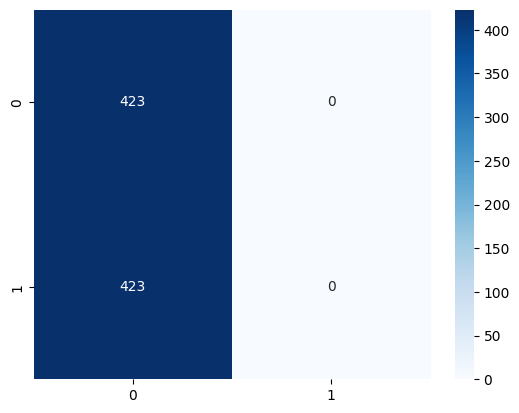

In [ ]:
confusion_matrix(tp_train, fp_train, fn_train, tn_train)

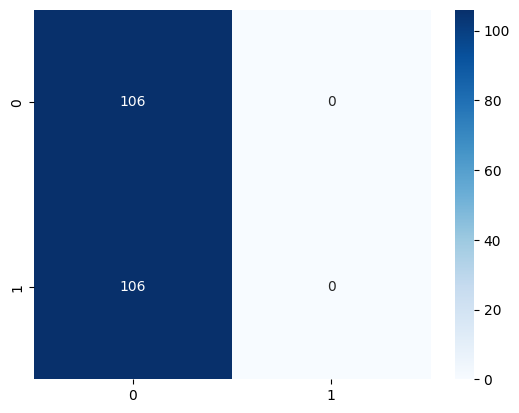

In [ ]:
confusion_matrix(tp_test, fp_test, fn_test, tn_test)


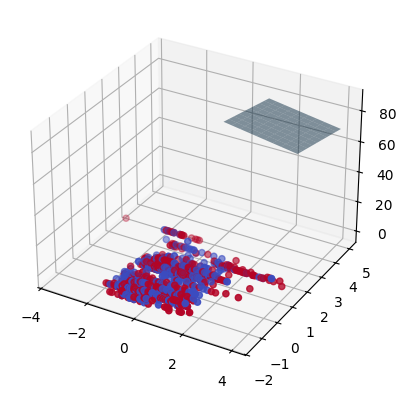

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# from sklearn.svm import SVC # Added import for SVC

# # Data
# X = np.array([[1, 2, 3], [2, 3, 4], [3, 4, 5], [4, 5, 6]])  # Fitur
# y = np.array([1, 1, -1, -1])  # Label kelas

# # Membuat objek SVM
# svm_model = SVC(kernel='linear')

# # Melatih model
# svm_model.fit(X, y)

# # Bobot (w) dan bias (b)
# w = svm_model.coef_[0]
# b = svm_model.intercept_[0]

# Plot data
X_array = X.values if hasattr(X, 'values') else np.array(X)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_array[:,0], X_array[:,1], X_array[:,2], c=y, cmap=plt.cm.coolwarm) # type: ignore

# Hyperplane
x1 = np.linspace(1, 4, 10)
x2 = np.linspace(2, 5, 10)
x1, x2 = np.meshgrid(x1, x2)
x3 = (-weights[0] * x1 - weights[1] * x2 - bias) / weights[2]
ax.plot_surface(x1, x2, x3, alpha=0.5)
plt.show()

In [ ]:
def visualize_svm(X, y, weights, bias):
    X = np.array(X)
    y = np.array(y)
    w = np.array(weights)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", alpha=0.7, edgecolors="k")
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)

    z = (w[0] * XX + w[1] * YY + bias)

    ax.contour(XX, YY, z, colors="k", levels=[-1, 0, 1], linestyles=["--", "-", "--"])

    plt.grid(True)
    plt.show()

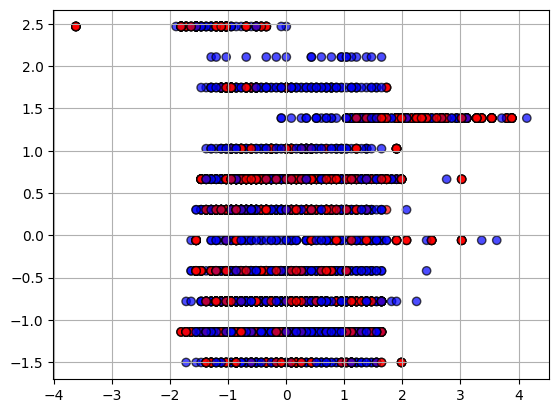

In [ ]:
visualize_svm(X_train, y_train, weights, bias)


In [136]:
root = tk.Tk()
root.configure(bg="#1A1E23")

def get_prediction():
    try:
        input_user_raw = np.zeros(X_train.shape[1]) 
        
        # 2. Scaling data input user (Wajib pakai scaler yang sama saat training!)
        input_scaled = scaler.transform(np.array([input_user_raw]))
        
        # 3. Prediksi
        pred_val = model_rbf.predict(input_scaled)[0]
        
        hasil_text = "Berlangganan (Yes)" if pred_val == 1 else "Tidak (No)"
        
        # Tampilkan
        messagebox.showinfo("Hasil Prediksi", f"Nasabah diprediksi: {hasil_text}")
        
    except Exception as e:
        messagebox.showerror("Error", f"Input error bang: {str(e)}")

# Frame
frame = tk.Frame(root)
frame.configure(bg="#1A1E23")
frame.place(relx=0.5, rely=0.35 ,anchor="center")

# label1
label1 = tk.Label(frame,
                  text="... Classifier",
                  font=("Arial", 40, "bold"),
                  bg="#1A1E23",
                  fg="#FFFFFF") 
label1.pack()

# entry1
entry1 = tk.Entry(frame,
                  font=("Arial", 30, 'bold'),
                  bg="#4C4C4C",
                  fg='#FFFFFF')
entry1.pack(pady=10)

# button1
button1 = tk.Button(frame,
                    text="Press",
                    font=("Arial", 26, "bold"),
                    bg="#4C4C4C",
                    fg="#FFFFFF",
                    command=get_prediction)
button1.pack()

root.mainloop()